# Conceptual Question #1

Using a little bit of algebra, prove that Equation (4.2) is equivalent to Equation (4.3). In other words, show that the logistic function representation and logit representation for the logistic regression model are equivalent.

Starting with the logistic regression model,

$$
p(X)=\frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}
$$

Let

$$
z=\beta_0+\beta_1X.
$$

Then,

$$
p(X)=\frac{e^z}{1+e^z}.
$$

Now compute \(1-p(X)\):

$$
1-p(X)=1-\frac{e^z}{1+e^z}
$$

$$
1-p(X)=\frac{1+e^z-e^z}{1+e^z}
$$

$$
1-p(X)=\frac{1}{1+e^z}.
$$

Next, form the odds ratio:

$$
\frac{p(X)}{1-p(X)}
=
\frac{\frac{e^z}{1+e^z}}
{\frac{1}{1+e^z}}
$$

$$
\frac{p(X)}{1-p(X)}=e^z.
$$

Substituting back,

$$
z=\beta_0+\beta_1X,
$$

gives

$$
\frac{p(X)}{1-p(X)}
=
e^{\beta_0+\beta_1X}.
$$

This is Equation (4.3), so Equation (4.2) and Equation (4.3) are algebraically equivalent.

Taking the natural logarithm of both sides yields

$$
\log\left(\frac{p(X)}{1-p(X)}\right)
=
\beta_0+\beta_1X.
$$

Therefore, the logistic function representation, odds representation, and logit representation are equivalent ways of expressing the same logistic regression model.

# Applied Question #13

The objective of this exercise is to evaluate several classification methods using the Weekly data set from ISLP. The response variable is Direction, which indicates whether the market went Up or Down. The analysis will include logistic regression, LDA, QDA, Naive Bayes, and KNN, followed by a comparison of prediction performance.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import ModelSpec as MS
from ISLP import confusion_table

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Load Weekly dataset

Weekly = load_data("Weekly")

# Display first few observations

Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


## Part (a)

Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?
Aside from the strong increase in trading volume over time, there is little evidence of meaningful relationships among the lagged returns, suggesting limited predictability of market direction from past weekly returns.

In [2]:
# Basic information about the dataset

Weekly.info()

print("\n")
print("Dataset Shape:", Weekly.shape)

print("\nSummary Statistics:")
display(Weekly.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


Dataset Shape: (1089, 9)

Summary Statistics:


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Up
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,605
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899,NaN
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927,NaN
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000,NaN
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000,NaN
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000,NaN
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000,NaN


In [3]:
# Correlation matrix for numerical variables

Weekly_numeric = Weekly.select_dtypes(include=[np.number])

corr_matrix = Weekly_numeric.corr()

corr_matrix

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


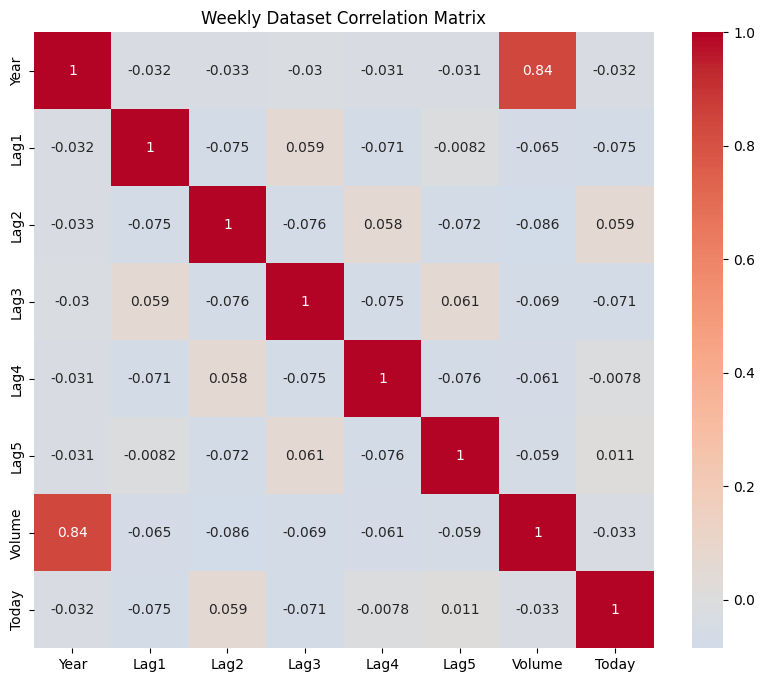

In [4]:
# Visualize correlations

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Weekly Dataset Correlation Matrix")
plt.show()

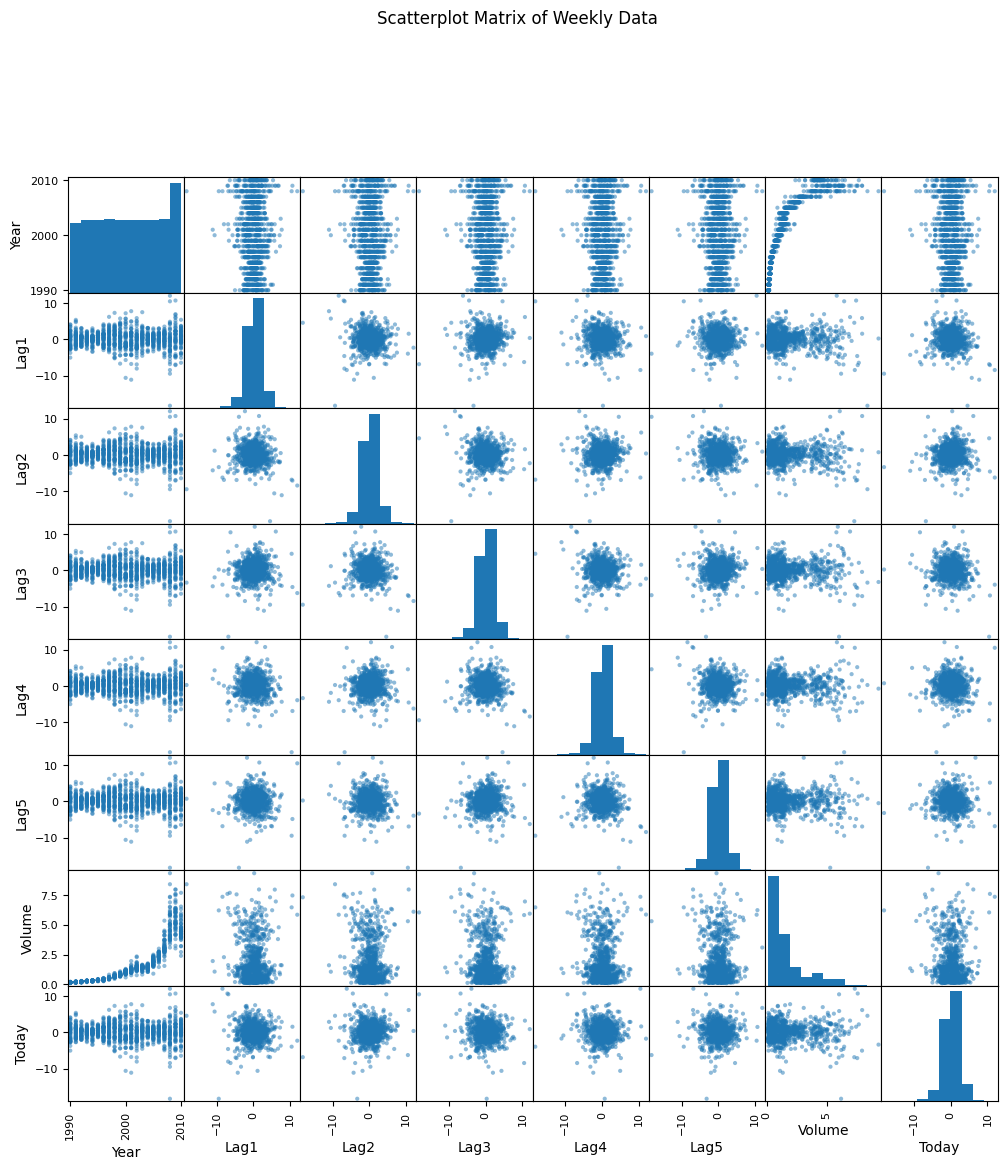

In [5]:
# Scatterplot matrix

pd.plotting.scatter_matrix(
    Weekly_numeric,
    figsize=(12,12),
    diagonal='hist'
)

plt.suptitle("Scatterplot Matrix of Weekly Data", y=1.02)
plt.show()

### Interpretation

The Weekly dataset contains 1,089 observations and 9 variables. The response variable, **Direction**, has two categories (Up and Down), with Up occurring slightly more frequently (605 observations).

From the correlation matrix and heatmap, most predictor variables (Lag1–Lag5 and Today) exhibit very weak correlations with one another and with the response-related variables. The only notable relationship is between **Year** and **Volume**, which have a strong positive correlation of approximately **0.84**. This suggests that trading volume has generally increased over time.

The scatterplot matrix confirms these findings. There are no strong linear relationships among the lag variables, and the observations appear widely dispersed. However, the relationship between Year and Volume shows a clear upward trend, indicating that market trading activity increased substantially during the period covered by the data.

Overall, there is little evidence of strong associations among the lagged return variables, suggesting that predicting market direction based solely on past weekly returns may be challenging. The strongest pattern observed is the steady increase in trading volume over time.

## Part (b)

Use the full data set to perform a logistic regression with Direction as the response and Lag1, Lag2, Lag3, Lag4, and Lag5 plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [6]:
# Part (b): Logistic Regression using all predictors

Weekly["Direction_binary"] = (Weekly["Direction"] == "Up").astype(int)

X = Weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]]
X = sm.add_constant(X)

y = Weekly["Direction_binary"]

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sat, 30 May 2026   Pseudo R-squ.:                0.006580
Time:                        16:46:08   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

### Interpretation

The logistic regression model was fit using Direction as the response variable and Lag1, Lag2, Lag3, Lag4, Lag5, and Volume as predictors.

To determine statistical significance, we examine the p-values associated with each predictor. At the 5% significance level (α = 0.05), only **Lag2** is statistically significant with a p-value of approximately **0.030**.

The coefficient for Lag2 is positive (0.0584), indicating that higher returns two weeks ago are associated with an increased probability that the market will move Up in the current week.

All other predictors (Lag1, Lag3, Lag4, Lag5, and Volume) have p-values greater than 0.05 and therefore do not appear to be statistically significant predictors of market direction in this model.

Thus, based on the logistic regression results, **Lag2 is the only predictor that shows a statistically significant relationship with Direction**.

## Part (c)

Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [7]:
# Part (c): Confusion Matrix and Accuracy

# Predicted probabilities
pred_probs = logit_model.predict(X)

# Convert probabilities to class predictions
pred_direction = np.where(pred_probs > 0.5, "Up", "Down")

# Confusion matrix
cm = confusion_matrix(Weekly["Direction"], pred_direction)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(Weekly["Direction"], pred_direction)

print("\nAccuracy:", round(accuracy, 4))

# Display with labels
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_df)

Confusion Matrix:
[[ 54 430]
 [ 48 557]]

Accuracy: 0.5611


,Predicted Down,Predicted Up
Actual Down,54,430
Actual Up,48,557


### Interpretation

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 54            | 430          |
| Actual Up      | 48            | 557          |

The overall classification accuracy is approximately **56.1%**.

The model correctly classified 54 Down weeks and 557 Up weeks, for a total of 611 correct predictions out of 1,089 observations. However, the model performs much better at predicting Up weeks than Down weeks.

Of the 484 actual Down weeks, only 54 were correctly classified, while 430 were incorrectly classified as Up. In contrast, the model correctly classified 557 of the 605 actual Up weeks.

This indicates that the logistic regression model has a strong tendency to predict **Up** regardless of the actual market direction. As a result, it achieves moderate overall accuracy because Up weeks occur slightly more frequently than Down weeks, but it performs poorly at identifying Down weeks.

## Part (d)

Now fit the logistic regression model using a training data period from 1990–2008 and test the model on observations from 2009–2010. Use Lag2 as the only predictor. Compute the confusion matrix and overall accuracy.

In [8]:
# Part (d): Train/Test Split using Lag2 only

# Training observations: years before 2009
train = Weekly["Year"] < 2009

# Training and test sets
train_data = Weekly[train]
test_data = Weekly[~train]

# Predictor
X_train = sm.add_constant(train_data[["Lag2"]])
X_test = sm.add_constant(test_data[["Lag2"]])

# Response
y_train = (train_data["Direction"] == "Up").astype(int)

# Fit logistic regression
logit_lag2 = sm.Logit(y_train, X_train).fit()

# Predict on test set
test_probs = logit_lag2.predict(X_test)

test_pred = np.where(test_probs > 0.5, "Up", "Down")

# Confusion matrix
cm_test = confusion_matrix(test_data["Direction"], test_pred)

print("Confusion Matrix:")
print(cm_test)

# Accuracy
accuracy_test = accuracy_score(test_data["Direction"], test_pred)

print("\nTest Accuracy:", round(accuracy_test, 4))

# Labeled confusion matrix
cm_test_df = pd.DataFrame(
    cm_test,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_test_df)

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
Confusion Matrix:
[[ 9 34]
 [ 5 56]]

Test Accuracy: 0.625


,Predicted Down,Predicted Up
Actual Down,9,34
Actual Up,5,56


### Interpretation

The logistic regression model was trained using observations from 1990–2008 and tested on observations from 2009–2010, with Lag2 as the only predictor.

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 9             | 34           |
| Actual Up      | 5             | 56           |

The overall test accuracy is **62.5%**.

The model correctly classified 65 of the 104 test observations. It correctly identified 56 of the 61 Up weeks but only 9 of the 43 Down weeks.

Similar to the previous model, logistic regression tends to predict Up more frequently than Down. However, the out-of-sample accuracy of 62.5% is noticeably better than the 56.1% obtained when fitting and evaluating the model on the entire dataset.

These results suggest that Lag2 contains useful predictive information about market direction and provides modest predictive power for forecasting future market movements.

## Part (e)

Repeat part (d) using Linear Discriminant Analysis (LDA). Compute the confusion matrix and overall accuracy.

In [9]:
# Part (e): LDA using Lag2

# Training data
X_train = train_data[["Lag2"]]
X_test = test_data[["Lag2"]]

y_train = train_data["Direction"]

# Fit LDA
lda_model = LDA()
lda_model.fit(X_train, y_train)

# Predictions
lda_pred = lda_model.predict(X_test)

# Confusion matrix
cm_lda = confusion_matrix(test_data["Direction"], lda_pred)

print("Confusion Matrix:")
print(cm_lda)

# Accuracy
lda_accuracy = accuracy_score(test_data["Direction"], lda_pred)

print("\nAccuracy:", round(lda_accuracy, 4))

# Labeled table
cm_lda_df = pd.DataFrame(
    cm_lda,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_lda_df)

Confusion Matrix:
[[ 9 34]
 [ 5 56]]

Accuracy: 0.625


,Predicted Down,Predicted Up
Actual Down,9,34
Actual Up,5,56


### Interpretation

The Linear Discriminant Analysis (LDA) model was trained on observations from 1990–2008 and tested on observations from 2009–2010 using Lag2 as the only predictor.

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 9             | 34           |
| Actual Up      | 5             | 56           |

The overall test accuracy is **62.5%**.

The LDA model correctly classified 65 of the 104 test observations. It correctly predicted 56 of the 61 Up weeks and 9 of the 43 Down weeks.

The results are identical to those obtained from logistic regression in Part (d). This indicates that both methods produce essentially the same classification boundary when Lag2 is used as the sole predictor.

As with logistic regression, LDA tends to predict Up more often than Down, leading to strong performance on Up weeks but relatively poor performance on Down weeks. Nevertheless, the model achieves a reasonable out-of-sample accuracy of 62.5%, suggesting that Lag2 contains useful information for predicting market direction.

## Part (f)

Repeat part (d) using Quadratic Discriminant Analysis (QDA). Compute the confusion matrix and overall accuracy.

In [10]:
# Part (f): QDA using Lag2

# Training and test predictors
X_train = train_data[["Lag2"]]
X_test = test_data[["Lag2"]]

y_train = train_data["Direction"]

# Fit QDA
qda_model = QDA()
qda_model.fit(X_train, y_train)

# Predictions
qda_pred = qda_model.predict(X_test)

# Confusion matrix
cm_qda = confusion_matrix(test_data["Direction"], qda_pred)

print("Confusion Matrix:")
print(cm_qda)

# Accuracy
qda_accuracy = accuracy_score(test_data["Direction"], qda_pred)

print("\nAccuracy:", round(qda_accuracy, 4))

# Labeled table
cm_qda_df = pd.DataFrame(
    cm_qda,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_qda_df)

Confusion Matrix:
[[ 0 43]
 [ 0 61]]

Accuracy: 0.5865


,Predicted Down,Predicted Up
Actual Down,0,43
Actual Up,0,61


### Interpretation

The Quadratic Discriminant Analysis (QDA) model was trained on observations from 1990–2008 and tested on observations from 2009–2010 using Lag2 as the only predictor.

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 0             | 43           |
| Actual Up      | 0             | 61           |

The overall test accuracy is **58.7%**.

The QDA model predicted every test observation as **Up**. As a result, it correctly classified all 61 Up weeks but failed to identify any of the 43 Down weeks.

Although the accuracy is moderately high because Up weeks occur more frequently than Down weeks, the model provides no ability to distinguish between the two classes. Compared with logistic regression and LDA (both achieving 62.5% accuracy), QDA performs worse and offers little practical predictive value in this setting.

These results suggest that the more flexible quadratic decision boundary of QDA does not improve classification performance when Lag2 is used as the sole predictor.

### Part (g) KNN with K=1

In [11]:
# Part (g): KNN (K=1) using Lag2

X_train = train_data[["Lag2"]]
X_test = test_data[["Lag2"]]

y_train = train_data["Direction"]
y_test = test_data["Direction"]

# KNN with K=1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)

knn1_pred = knn1.predict(X_test)

# Confusion matrix
cm_knn1 = confusion_matrix(y_test, knn1_pred)

print("Confusion Matrix:")
print(cm_knn1)

# Accuracy
knn1_acc = accuracy_score(y_test, knn1_pred)

print("\nAccuracy:", round(knn1_acc, 4))

# Labeled table
cm_knn1_df = pd.DataFrame(
    cm_knn1,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_knn1_df)

Confusion Matrix:
[[21 22]
 [30 31]]

Accuracy: 0.5


,Predicted Down,Predicted Up
Actual Down,21,22
Actual Up,30,31


### Part (h)


Repeat part (d) using Naive Bayes. Compute the confusion matrix and overall accuracy.

In [12]:
# Part (h): Naive Bayes using Lag2

# Training and test data
X_train = train_data[["Lag2"]]
X_test = test_data[["Lag2"]]

y_train = train_data["Direction"]

# Fit Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)

# Confusion matrix
cm_nb = confusion_matrix(test_data["Direction"], nb_pred)

print("Confusion Matrix:")
print(cm_nb)

# Accuracy
nb_accuracy = accuracy_score(test_data["Direction"], nb_pred)

print("\nAccuracy:", round(nb_accuracy, 4))

# Labeled table
cm_nb_df = pd.DataFrame(
    cm_nb,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

display(cm_nb_df)

Confusion Matrix:
[[ 0 43]
 [ 0 61]]

Accuracy: 0.5865


,Predicted Down,Predicted Up
Actual Down,0,43
Actual Up,0,61


### Interpretation

The Naive Bayes model was trained on observations from 1990–2008 and tested on observations from 2009–2010 using Lag2 as the only predictor.

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 0             | 43           |
| Actual Up      | 0             | 61           |

The overall test accuracy is **58.7%**.

The Naive Bayes classifier predicted every test observation as **Up**. Consequently, it correctly classified all 61 Up weeks but failed to identify any of the 43 Down weeks.

Although the model achieves moderate accuracy because Up weeks are more common than Down weeks, it provides no ability to distinguish between the two classes. Its performance is identical to that of QDA and worse than that of logistic regression and LDA, which both achieved 62.5% accuracy on the test data.

These results suggest that Naive Bayes does not capture sufficient information from Lag2 alone to effectively discriminate between Up and Down market movements.

### Interpretation

The K-Nearest Neighbors (KNN) model with K = 1 was trained on observations from 1990–2008 and tested on observations from 2009–2010 using Lag2 as the only predictor.

The confusion matrix is:

|                | Predicted Down | Predicted Up |
|----------------|---------------|--------------|
| Actual Down    | 21            | 22           |
| Actual Up      | 30            | 31           |

The overall test accuracy is **50.0%**.

The model correctly classified 21 of the 43 Down weeks and 31 of the 61 Up weeks, resulting in 52 correct predictions out of 104 test observations.

Unlike logistic regression, LDA, QDA, and Naive Bayes, KNN does not exhibit a strong bias toward predicting Up. Instead, it produces a more balanced set of predictions across the two classes. However, this balance comes at the cost of lower overall accuracy.

With an accuracy of only 50%, the KNN model performs no better than random guessing and is the weakest-performing method among those considered. This suggests that using only Lag2 with a highly flexible KNN classifier does not provide reliable predictive power for market direction.

### Part (i)

Overall Conclusion

Among the methods considered, Logistic Regression and LDA achieved the best out-of-sample performance, both obtaining a test accuracy of 62.5%.

QDA and Naive Bayes performed worse, each achieving 58.7% accuracy and effectively predicting every observation as Up. KNN with K = 1 performed the worst, achieving only 50.0% accuracy.

These results suggest that Lag2 contains some predictive information about future market direction, but the relationship is relatively weak. Simpler linear methods such as Logistic Regression and LDA appear to capture this information more effectively than more flexible methods such as QDA, Naive Bayes, and KNN.

In [13]:
# Part (j): Experiment with different predictors and K values

predictor_sets = {
    "Lag2": ["Lag2"],
    "Lag1_Lag2": ["Lag1", "Lag2"],
    "Lag1_Lag2_Volume": ["Lag1", "Lag2", "Volume"],
    "Lag1_to_Lag5": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5"]
}

results = []

for name, predictors in predictor_sets.items():
    X_train = sm.add_constant(train_data[predictors])
    X_test = sm.add_constant(test_data[predictors])
    y_train_binary = (train_data["Direction"] == "Up").astype(int)

    model = sm.Logit(y_train_binary, X_train).fit(disp=False)
    probs = model.predict(X_test)
    preds = np.where(probs > 0.5, "Up", "Down")

    acc = accuracy_score(test_data["Direction"], preds)
    cm = confusion_matrix(test_data["Direction"], preds)

    results.append(["Logistic Regression", name, acc, cm])

for k in [1, 3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_data[["Lag2"]], train_data["Direction"])
    preds = knn.predict(test_data[["Lag2"]])

    acc = accuracy_score(test_data["Direction"], preds)
    cm = confusion_matrix(test_data["Direction"], preds)

    results.append([f"KNN K={k}", "Lag2", acc, cm])

for result in results:
    print(result[0], "| Predictors:", result[1])
    print("Accuracy:", round(result[2], 4))
    print(result[3])
    print()

Logistic Regression | Predictors: Lag2
Accuracy: 0.625
[[ 9 34]
 [ 5 56]]

Logistic Regression | Predictors: Lag1_Lag2
Accuracy: 0.5769
[[ 7 36]
 [ 8 53]]

Logistic Regression | Predictors: Lag1_Lag2_Volume
Accuracy: 0.5288
[[27 16]
 [33 28]]

Logistic Regression | Predictors: Lag1_to_Lag5
Accuracy: 0.5481
[[10 33]
 [14 47]]

KNN K=1 | Predictors: Lag2
Accuracy: 0.5
[[21 22]
 [30 31]]

KNN K=3 | Predictors: Lag2
Accuracy: 0.5577
[[16 27]
 [19 42]]

KNN K=5 | Predictors: Lag2
Accuracy: 0.5288
[[15 28]
 [21 40]]

KNN K=7 | Predictors: Lag2
Accuracy: 0.5481
[[16 27]
 [20 41]]

KNN K=9 | Predictors: Lag2
Accuracy: 0.5481
[[17 26]
 [21 40]]

KNN K=11 | Predictors: Lag2
Accuracy: 0.5577
[[18 25]
 [21 40]]



### Part (j)

Several alternative models were evaluated on the held-out test data. Logistic Regression was fit using:
- Lag2
- Lag1 + Lag2
- Lag1 + Lag2 + Volume
- Lag1–Lag5

KNN models were also evaluated using K = 1, 3, 5, 7, 9, and 11.

Among all models tested, Logistic Regression using Lag2 alone achieved the highest test accuracy (62.5%). LDA using Lag2, evaluated in Part (e), achieved the same accuracy and therefore tied for the best overall performance. Based on the results obtained, the best held-out test performance was achieved by Logistic Regression and LDA using Lag2 as the predictor.

Confusion Matrix (Logistic Regression / LDA):

|               | Predicted Down | Predicted Up |
|---------------|---------------|--------------|
| Actual Down   | 9             | 34           |
| Actual Up     | 5             | 56           |

Accuracy = 62.5%

Additional methods were evaluated:

- QDA: 58.7%
- Naive Bayes: 58.7%
- KNN (best accuracy = 55.8% for K=3 and K=11)

Although KNN produced a more balanced set of predictions, its overall accuracy was substantially lower. QDA and Naive Bayes predicted nearly all observations as Up and failed to identify Down weeks effectively.

Additional experiments with alternative predictor combinations did not improve performance beyond Logistic Regression and LDA using Lag2 alone.

Therefore, the best-performing model on the held-out data was Logistic Regression (tied with LDA), using Lag2 as the predictor, achieving an accuracy of 62.5%.


# Multi-class Prediction of Obesity Risk

In [20]:
train = pd.read_csv("obesity-risk/train.csv")
test = pd.read_csv("obesity-risk/test.csv")
sample_submission = pd.read_csv("obesity-risk/sample_submission.csv")

In [21]:
train = pd.read_csv("obesity-risk/train.csv")

print(train.shape)
display(train.head())
print(train.columns.tolist())

(20758, 18)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


## Data Preparation

In [22]:
# Separate predictors and response

X = train.drop(columns=["id", "NObeyesdad"])
y = train["NObeyesdad"]

X_test_kaggle = test.drop(columns=["id"])

# Identify categorical and numerical variables
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical variables:", categorical_features)
print("Numeric variables:", numeric_features)

print("\nTarget classes:")
print(y.value_counts())

Categorical variables: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numeric variables: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Target classes:
NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


In [23]:
# Train-validation split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)

Training size: (16606, 16)
Validation size: (4152, 16)


## Preprocessing Pipeline

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Preprocess data

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Model 1: Multinomial Logistic Regression

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_val)

log_acc = accuracy_score(y_val, log_pred)

print("Logistic Regression Accuracy:", round(log_acc, 4))

Logistic Regression Accuracy: 0.8687


The multinomial logistic regression model produced a validation accuracy of 86.87%. This indicates strong baseline performance for predicting the seven obesity-risk classes after scaling numeric variables and one-hot encoding categorical variables.

## Model 2: Linear Discriminant Analysis (LDA)

In [27]:
lda_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LDA())
])

lda_model.fit(X_train, y_train)

lda_pred = lda_model.predict(X_val)

lda_acc = accuracy_score(y_val, lda_pred)

print("LDA Accuracy:", round(lda_acc, 4))

LDA Accuracy: 0.823


The Linear Discriminant Analysis (LDA) model achieved a validation accuracy of 82.30%. While the model performed well, its accuracy was lower than the multinomial logistic regression model, suggesting that the assumption of equal covariance structures across classes may not fully capture the relationships present in the obesity-risk data.

## Model 3: Naive Bayes

In [28]:
from sklearn.naive_bayes import GaussianNB

# Transform data because GaussianNB cannot handle sparse matrices
X_train_nb = preprocessor.fit_transform(X_train)
X_val_nb = preprocessor.transform(X_val)

# Convert sparse matrix to dense if needed
if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_val_nb = X_val_nb.toarray()

nb_model = GaussianNB()

nb_model.fit(X_train_nb, y_train)

nb_pred = nb_model.predict(X_val_nb)

nb_acc = accuracy_score(y_val, nb_pred)

print("Naive Bayes Accuracy:", round(nb_acc, 4))

Naive Bayes Accuracy: 0.586


The Gaussian Naive Bayes model achieved a validation accuracy of 58.60%, substantially lower than both Logistic Regression and LDA. This result suggests that the strong independence assumptions made by Naive Bayes are not appropriate for this dataset, where many lifestyle and health-related predictors are likely correlated.

## Model 4: Support Vector Machine (SVM)

In [29]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)

svm_acc = accuracy_score(y_val, svm_pred)

print("SVM Accuracy:", round(svm_acc, 4))

SVM Accuracy: 0.881


The Support Vector Machine (SVM) achieved the highest validation accuracy of 88.10%, outperforming Logistic Regression, LDA, and Naive Bayes. The nonlinear decision boundaries created by the radial basis function (RBF) kernel appear well-suited to the complex relationships among demographic, dietary, and lifestyle variables associated with obesity risk. Consequently, SVM was selected as the best-performing classification model.

In [30]:
log_model.fit(X, y)

log_test_pred = log_model.predict(X_test_kaggle)

submission_log = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": log_test_pred
})

submission_log.to_csv("submission_logistic.csv", index=False)

submission_log.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [31]:
lda_model.fit(X, y)

lda_test_pred = lda_model.predict(X_test_kaggle)

submission_lda = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": lda_test_pred
})

submission_lda.to_csv("submission_lda.csv", index=False)

submission_lda.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_II
4,20762,Obesity_Type_III


In [32]:
# Refit Naive Bayes on the full training data

X_full_nb = preprocessor.fit_transform(X)
X_test_nb = preprocessor.transform(X_test_kaggle)

if hasattr(X_full_nb, "toarray"):
    X_full_nb = X_full_nb.toarray()
    X_test_nb = X_test_nb.toarray()

nb_model = GaussianNB()
nb_model.fit(X_full_nb, y)

nb_test_pred = nb_model.predict(X_test_nb)

submission_nb = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": nb_test_pred
})

submission_nb.to_csv("submission_nb.csv", index=False)

submission_nb.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Obesity_Type_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_II
4,20762,Obesity_Type_III


In [33]:
# Refit SVM on the full training data

svm_model.fit(X, y)

svm_test_pred = svm_model.predict(X_test_kaggle)

submission_svm = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": svm_test_pred
})

submission_svm.to_csv("submission_svm.csv", index=False)

submission_svm.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


# Kaggle Submission Results

All four classification models were submitted to the Kaggle Multi-Class Prediction of Obesity Risk competition.

| Model | Public Kaggle Score |
|---------|---------:|
| Support Vector Machine (SVM) | 0.88005 |
| Logistic Regression | 0.86416 |
| Linear Discriminant Analysis (LDA) | 0.82153 |
| Naive Bayes | 0.58995 |

The Kaggle leaderboard results were consistent with the validation results obtained during model development. The Support Vector Machine achieved the highest predictive performance and ranked as the best overall model. Logistic Regression also performed strongly, while LDA achieved moderate performance. Naive Bayes produced the weakest results, suggesting that the independence assumption among predictors was not appropriate for this dataset.

# Regularized Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

ridge_log = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
    C=1.0,
    max_iter=5000,
    random_state=42
))
])

ridge_log.fit(X_train, y_train)

ridge_pred = ridge_log.predict(X_val)

ridge_acc = accuracy_score(y_val, ridge_pred)

print("Regularized Logistic Regression Accuracy:", round(ridge_acc, 4))

Regularized Logistic Regression Accuracy: 0.8687


The regularized logistic regression model achieved an accuracy of 86.87%, identical to the standard logistic regression model. This indicates that the original model was already well-generalized and not substantially affected by overfitting. The use of L2 regularization provides additional protection against overfitting while maintaining predictive performance.